=== EVALUACIÓN ===
Loss: 0.26229435205459595
Accuracy (keras): 0.956417441368103
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step

=== MÉTRICAS ===
              precision    recall  f1-score       support
0              0.963609  0.977107  0.970311  12493.000000
1              0.974232  0.927446  0.950263  10599.000000
2              0.869469  0.977612  0.920375   1206.000000
3              0.888889  0.998051  0.940312    513.000000
4              0.453659  1.000000  0.624161     93.000000
5              0.782609  1.000000  0.878049     54.000000
6              1.000000  0.944444  0.971429     36.000000
7              1.000000  1.000000  1.000000      6.000000
8              1.000000  0.800000  0.888889      5.000000
9              0.500000  0.200000  0.285714      5.000000
accuracy       0.956417  0.956417  0.956417      0.956417
macro avg      0.843247  0.882466  0.842950  25010.000000
weighted avg   0.959727  0.956417  0.957161  25010.000000

=== ACCURACY GLOBAL ===
Accuracy: 0.956417433

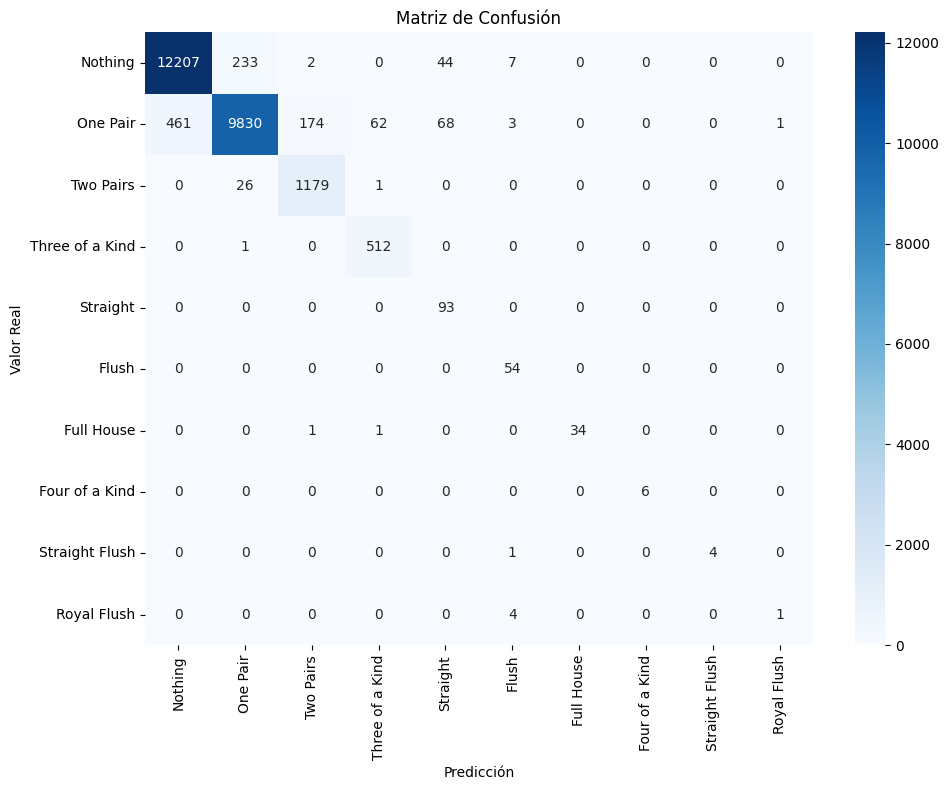

In [9]:
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==============================
# 1. CARGAR MODELO
# ==============================
modelo = load_model("./chckpnt/myBaby.keras")

# ==============================
# 2. CARGAR DATASET
# ==============================
df_test = pd.read_csv("../../preprocesamiento/preprocesamiento_test.data", header=None)

X_test = df_test.iloc[:, :-1].values
y_test = df_test.iloc[:, -1].values

# ==============================
# 3. EVALUAR
# ==============================
loss, accuracy = modelo.evaluate(X_test, y_test, verbose=0)

print("=== EVALUACIÓN ===")
print("Loss:", loss)
print("Accuracy (keras):", accuracy)

# ==============================
# 4. PREDICCIONES
# ==============================
pred = modelo.predict(X_test)
y_pred = pred.argmax(axis=1)

# ==============================
# 6. MÉTRICAS EN PANDAS
# ==============================
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

print("\n=== MÉTRICAS ===")
print(df_report)

# ==============================
# 7. ACCURACY GLOBAL
# ==============================
acc = accuracy_score(y_test, y_pred)

print("\n=== ACCURACY GLOBAL ===")
print("Accuracy: " + str(acc))

recall = df_report.loc["weighted avg", "recall"]
print("Recall: " + str(recall))

f1_score = df_report.loc["weighted avg", "f1-score"]
print("F1-Score: " + str(f1_score))

import seaborn as sns
import matplotlib.pyplot as plt

# Etiquetas (opcional pero recomendado)
labels = [
    "Nothing", "One Pair", "Two Pairs", "Three of a Kind",
    "Straight", "Flush", "Full House",
    "Four of a Kind", "Straight Flush", "Royal Flush"
]

# Crear DataFrame de la matriz
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)

# ==============================
# GRAFICAR MATRIZ DE CONFUSIÓN
# ==============================
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_cm,
    annot=True,        # números dentro
    fmt="d",           # formato entero
    cmap="Blues",      # colores
    cbar=True
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()
plt.show()